## Модели прогнозирования количества яиц по Жамбылской области

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

### Подготовка данных и EDA

In [2]:
df = pd.read_excel("Датасет по яйцам с регрессорами.xlsx")
df = df[['Регион', 'Период', 'Яйца', 'Осадки', 'Поголовье: птица домашняя', 'Температура', 'Цена: Яйца']]
df.sample(10)

,Регион,Период,Яйца,Осадки,Поголовье: птица домашняя,Температура,Цена: Яйца
356,АЛМАТИНСКАЯ ОБЛАСТЬ,2024-09,46554.1,32.7,9678533.0,13.726667,202.295034
85,АКМОЛИНСКАЯ ОБЛАСТЬ,2022-02,51263.2,13.0,9306544.0,-9.200000,149.564423
572,ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2022-09,8232.3,5.9,3732617.0,14.573333,318.101893
1138,ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2023-04,14144.5,21.3,1095632.0,10.850000,270.151009
988,ЖАМБЫЛСКАЯ ОБЛАСТЬ,2020-10,11300.3,0.5,1704006.0,8.903226,151.135952
492,ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2016-01,6359.1,20.4,3728982.0,-16.341935,127.237523
1554,МАНГИСТАУСКАЯ ОБЛАСТЬ,2017-12,491.9,29.3,36481.0,0.958065,NaN
1243,КАРАГАНДИНСКАЯ ОБЛАСТЬ,2022-01,46241.2,12.2,3283584.0,-10.222581,229.900861
484,ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2015-05,18897.3,63.8,3509041.0,14.774194,102.500000
969,ЖАМБЫЛСКАЯ ОБЛАСТЬ,2019-03,8503.4,34.7,1357701.0,8.725806,111.124813


In [3]:
df_zhambyl = df[df['Регион'] == 'ЖАМБЫЛСКАЯ ОБЛАСТЬ']
df_zhambyl = df_zhambyl.drop('Регион', axis = 'columns')
df_zhambyl.head()

,Период,Яйца,Осадки,Поголовье: птица домашняя,Температура,Цена: Яйца
919,2015-01,6679.3,48.5,1090817.0,-2.306452,100.000
920,2015-02,5882.9,25.3,1064009.0,1.871429,91.500
921,2015-03,8486.3,36.2,1058752.0,3.958065,91.500
922,2015-04,9293.0,25.4,1099098.0,14.166667,91.500
923,2015-05,12289.6,16.4,1170091.0,20.106452,82.533


In [4]:
df_zhambyl = df_zhambyl.rename(columns={'Яйца': 'Кол-во яиц'})
df_zhambyl.head()

,Период,Кол-во яиц,Осадки,Поголовье: птица домашняя,Температура,Цена: Яйца
919,2015-01,6679.3,48.5,1090817.0,-2.306452,100.000
920,2015-02,5882.9,25.3,1064009.0,1.871429,91.500
921,2015-03,8486.3,36.2,1058752.0,3.958065,91.500
922,2015-04,9293.0,25.4,1099098.0,14.166667,91.500
923,2015-05,12289.6,16.4,1170091.0,20.106452,82.533


In [5]:
df_zhambyl['Период'] = pd.to_datetime(df_zhambyl['Период'], format='%Y-%m')
df_zhambyl.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120 entries, 919 to 1038
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Период                     120 non-null    datetime64[ns]
 1   Кол-во яиц                 120 non-null    float64       
 2   Осадки                     120 non-null    float64       
 3   Поголовье: птица домашняя  120 non-null    float64       
 4   Температура                120 non-null    float64       
 5   Цена: Яйца                 120 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 6.6 KB


In [6]:
df_zhambyl.isna().sum()

Период                       0
Кол-во яиц                   0
Осадки                       0
Поголовье: птица домашняя    0
Температура                  0
Цена: Яйца                   0
dtype: int64

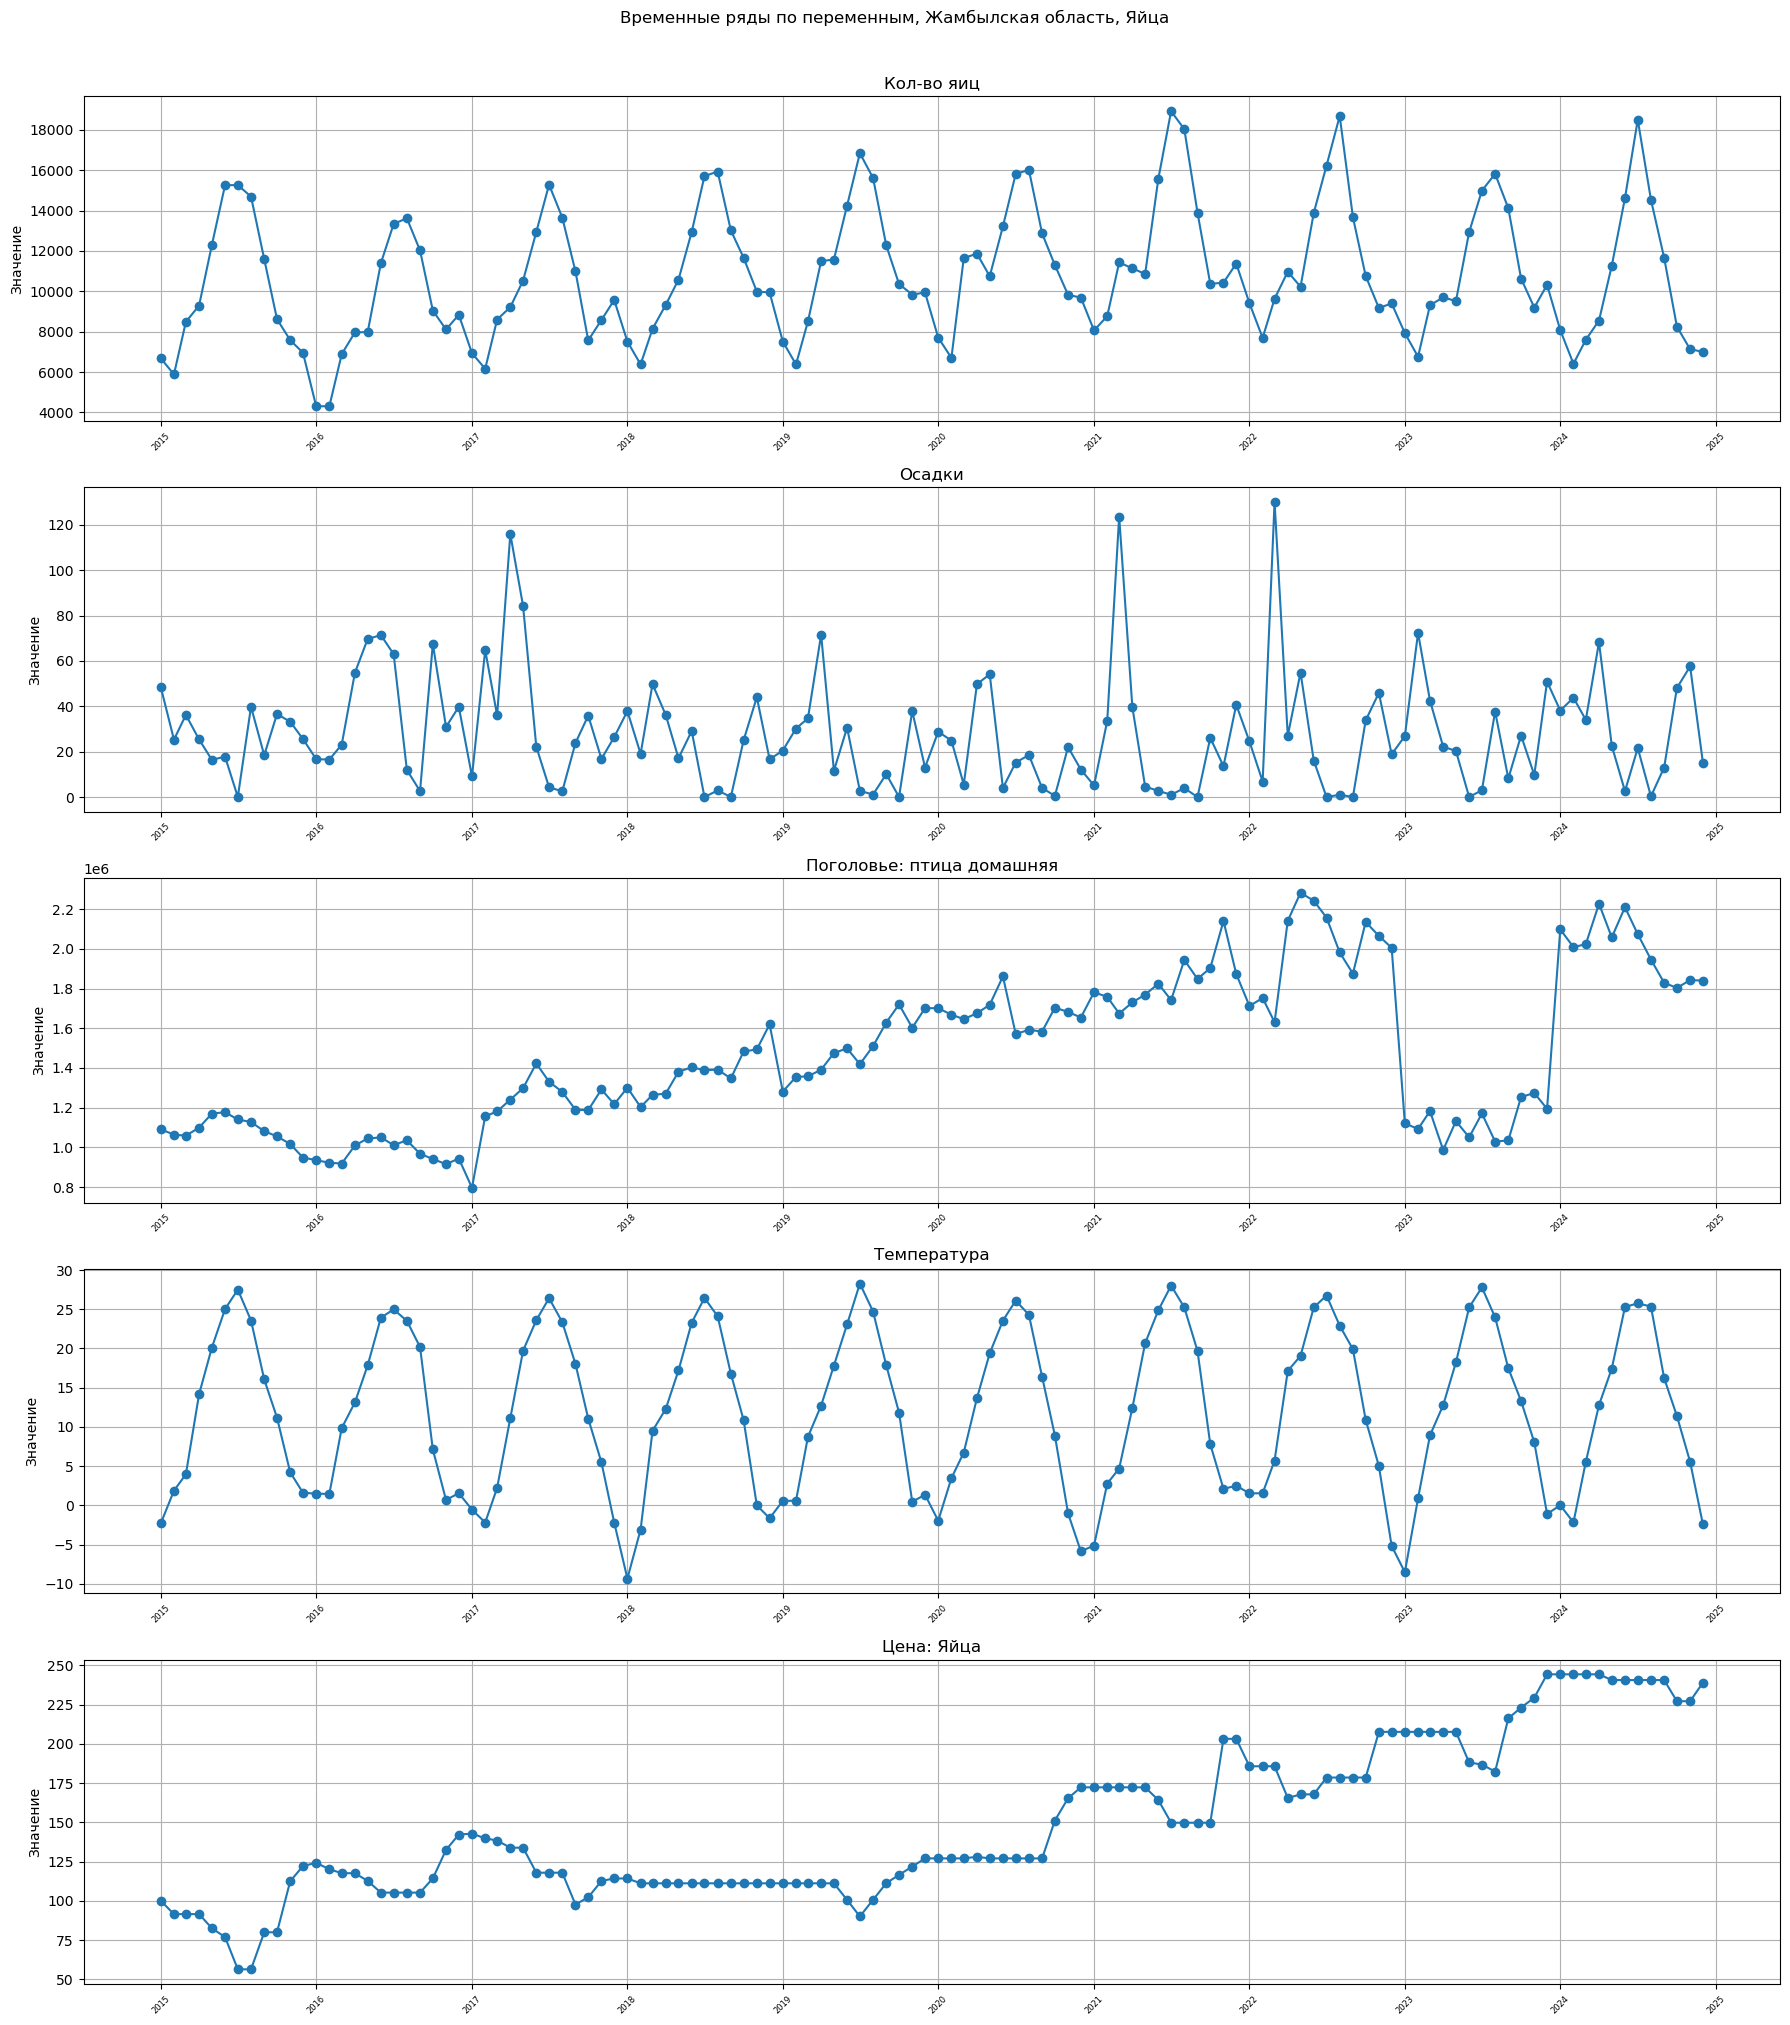

In [7]:
# Plot each variable in its own subplot
value_cols = [col for col in df_zhambyl.columns if col not in ["Период"]]

n = len(value_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(value_cols, 1):
    plt.subplot(n, 1, i)
    plt.plot(df_zhambyl["Период"], df_zhambyl[col], marker="o")
    plt.title(f"{col}")
    plt.grid(True)
    plt.ylabel("Значение")
    plt.xticks(rotation=45, fontsize = 6)

plt.suptitle("Временные ряды по переменным, Жамбылская область, Яйца", y=1.01)
plt.tight_layout()
plt.show()

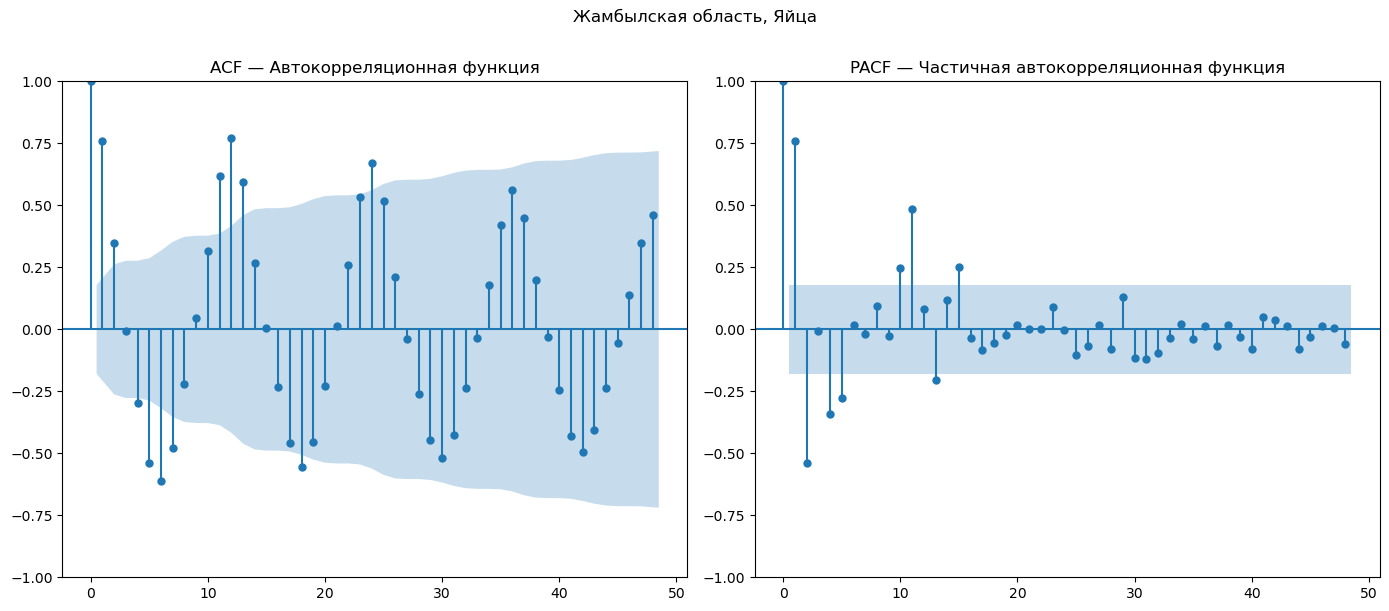

In [8]:
y = df_zhambyl["Кол-во яиц"].sort_index()

# Plot ACF and PACF
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_acf(y, lags=48, ax=plt.gca(), title="ACF — Автокорреляционная функция")

plt.subplot(1, 2, 2)
plot_pacf(y, lags=48, ax=plt.gca(), title="PACF — Частичная автокорреляционная функция", method="ywm")
plt.suptitle("Жамбылская область, Яйца", y=1.01)

plt.tight_layout()
plt.show()

Графики автокорреляционной и частичной автокорреляционной функций указывают на **сильную взаимосвязь показателей текущего месяца со значениями следующих 3 месяцев** и на возможную **годовую сезонность** (пик на +12 месяцев). 

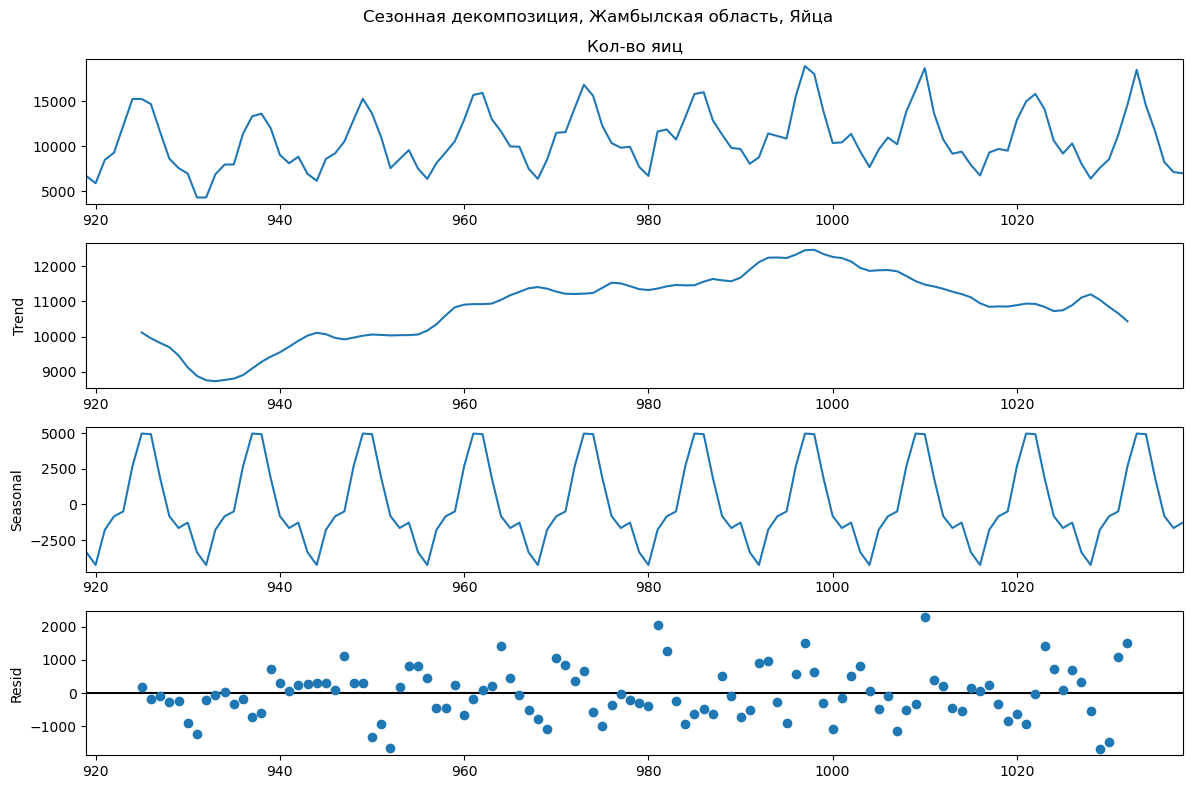

In [9]:
# Perform decomposition (period=12 for monthly data)
decomposition = seasonal_decompose(df_zhambyl["Кол-во яиц"], model="additive", period=12)

# Plot with larger figure size
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Сезонная декомпозиция, Жамбылская область, Яйца", fontsize=12)
plt.tight_layout()
plt.show()


In [10]:
# Run ADF test
result = adfuller(df_zhambyl["Кол-во яиц"])

# Display results
print("📊 Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

# Interpretation
if result[1] < 0.05:
    print("✅ The series is likely **stationary** (reject H₀).")
else:
    print("❌ The series is likely **non-stationary** (fail to reject H₀).")


📊 Augmented Dickey-Fuller Test Results:
ADF Statistic: -1.4129
p-value: 0.5761
Critical Value (1%): -3.4930
Critical Value (5%): -2.8890
Critical Value (10%): -2.5814
❌ The series is likely **non-stationary** (fail to reject H₀).


Результаты теста ADF указывают на **нестационарность** временного ряда.

In [11]:
df_zhambyl

,Период,Кол-во яиц,Осадки,Поголовье: птица домашняя,Температура,Цена: Яйца
919,2015-01-01,6679.3,48.5,1090817.0,-2.306452,100.000000
920,2015-02-01,5882.9,25.3,1064009.0,1.871429,91.500000
921,2015-03-01,8486.3,36.2,1058752.0,3.958065,91.500000
922,2015-04-01,9293.0,25.4,1099098.0,14.166667,91.500000
923,2015-05-01,12289.6,16.4,1170091.0,20.106452,82.533000
...,...,...,...,...,...,...
1034,2024-08-01,14534.9,0.3,1946648.0,25.345161,240.643543
1035,2024-09-01,11659.5,13.0,1829054.0,16.213333,240.643543
1036,2024-10-01,8246.6,48.1,1803775.0,11.387097,227.167505
1037,2024-11-01,7127.0,57.6,1842863.0,5.546667,227.167505


In [12]:
# Создание лагов t-1 до t-6 для переменных
for lag in range(1, 7):
    df_zhambyl[f"Яйца_t-{lag}"] = df_zhambyl["Кол-во яиц"].shift(lag)
    df_zhambyl[f"Температура_t-{lag}"] = df_zhambyl["Температура"].shift(lag)
    df_zhambyl[f"Осадки_t-{lag}"] = df_zhambyl["Осадки"].shift(lag)
    df_zhambyl[f"Поголовье: птица домашняя_t-{lag}"] = df_zhambyl["Поголовье: птица домашняя"].shift(lag)
    df_zhambyl[f"Цена: Яйца_t-{lag}"] = df_zhambyl["Цена: Яйца"].shift(lag)

df_zhambyl_full = df_zhambyl[["Период", "Кол-во яиц", 
                            "Яйца_t-1", "Яйца_t-2", "Яйца_t-3", "Яйца_t-4", "Яйца_t-5", "Яйца_t-6",
                            "Температура", "Температура_t-1", "Температура_t-2", "Температура_t-3", "Температура_t-4", "Температура_t-5", "Температура_t-6",
                            "Осадки", "Осадки_t-1", "Осадки_t-2", "Осадки_t-3", "Осадки_t-4", "Осадки_t-5", "Осадки_t-6",
                            "Поголовье: птица домашняя", "Поголовье: птица домашняя_t-1", "Поголовье: птица домашняя_t-2", "Поголовье: птица домашняя_t-3", "Поголовье: птица домашняя_t-4", "Поголовье: птица домашняя_t-5", "Поголовье: птица домашняя_t-6",
                            "Цена: Яйца", "Цена: Яйца_t-1", "Цена: Яйца_t-2", "Цена: Яйца_t-3", "Цена: Яйца_t-4", "Цена: Яйца_t-5", "Цена: Яйца_t-6"]]
df_zhambyl_full

,Период,Кол-во яиц,Яйца_t-1,Яйца_t-2,Яйца_t-3,Яйца_t-4,Яйца_t-5,Яйца_t-6,Температура,Температура_t-1,Температура_t-2,Температура_t-3,Температура_t-4,Температура_t-5,Температура_t-6,Осадки,Осадки_t-1,Осадки_t-2,Осадки_t-3,Осадки_t-4,Осадки_t-5,Осадки_t-6,Поголовье: птица домашняя,Поголовье: птица домашняя_t-1,Поголовье: птица домашняя_t-2,Поголовье: птица домашняя_t-3,Поголовье: птица домашняя_t-4,Поголовье: птица домашняя_t-5,Поголовье: птица домашняя_t-6,Цена: Яйца,Цена: Яйца_t-1,Цена: Яйца_t-2,Цена: Яйца_t-3,Цена: Яйца_t-4,Цена: Яйца_t-5,Цена: Яйца_t-6
919,2015-01-01,6679.3,NaN,NaN,NaN,NaN,NaN,NaN,-2.306452,NaN,NaN,NaN,NaN,NaN,NaN,48.5,NaN,NaN,NaN,NaN,NaN,NaN,1090817.0,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN,NaN
920,2015-02-01,5882.9,6679.3,NaN,NaN,NaN,NaN,NaN,1.871429,-2.306452,NaN,NaN,NaN,NaN,NaN,25.3,48.5,NaN,NaN,NaN,NaN,NaN,1064009.0,1090817.0,NaN,NaN,NaN,NaN,NaN,91.500000,100.000000,NaN,NaN,NaN,NaN,NaN
921,2015-03-01,8486.3,5882.9,6679.3,NaN,NaN,NaN,NaN,3.958065,1.871429,-2.306452,NaN,NaN,NaN,NaN,36.2,25.3,48.5,NaN,NaN,NaN,NaN,1058752.0,1064009.0,1090817.0,NaN,NaN,NaN,NaN,91.500000,91.500000,100.000000,NaN,NaN,NaN,NaN
922,2015-04-01,9293.0,8486.3,5882.9,6679.3,NaN,NaN,NaN,14.166667,3.958065,1.871429,-2.306452,NaN,NaN,NaN,25.4,36.2,25.3,48.5,NaN,NaN,NaN,1099098.0,1058752.0,1064009.0,1090817.0,NaN,NaN,NaN,91.500000,91.500000,91.500000,100.000000,NaN,NaN,NaN
923,2015-05-01,12289.6,9293.0,8486.3,5882.9,6679.3,NaN,NaN,20.106452,14.166667,3.958065,1.871429,-2.306452,NaN,NaN,16.4,25.4,36.2,25.3,48.5,NaN,NaN,1170091.0,1099098.0,1058752.0,1064009.0,1090817.0,NaN,NaN,82.533000,91.500000,91.500000,91.500000,100.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,2024-08-01,14534.9,18504.3,14618.4,11266.8,8548.5,7596.5,6406.5,25.345161,25.758065,25.286667,17.441935,12.786667,5.535484,-2.175862,0.3,21.6,2.6,22.6,68.3,34.0,43.8,1946648.0,2074454.0,2210507.0,2058151.0,2227639.0,2023626.0,2009570.0,240.643543,240.643543,240.643543,240.643543,244.308166,244.308166,244.308166
1035,2024-09-01,11659.5,14534.9,18504.3,14618.4,11266.8,8548.5,7596.5,16.213333,25.345161,25.758065,25.286667,17.441935,12.786667,5.535484,13.0,0.3,21.6,2.6,22.6,68.3,34.0,1829054.0,1946648.0,2074454.0,2210507.0,2058151.0,2227639.0,2023626.0,240.643543,240.643543,240.643543,240.643543,240.643543,244.308166,244.308166
1036,2024-10-01,8246.6,11659.5,14534.9,18504.3,14618.4,11266.8,8548.5,11.387097,16.213333,25.345161,25.758065,25.286667,17.441935,12.786667,48.1,13.0,0.3,21.6,2.6,22.6,68.3,1803775.0,1829054.0,1946648.0,2074454.0,2210507.0,2058151.0,2227639.0,227.167505,240.643543,240.643543,240.643543,240.643543,240.643543,244.308166
1037,2024-11-01,7127.0,8246.6,11659.5,14534.9,18504.3,14618.4,11266.8,5.546667,11.387097,16.213333,25.345161,25.758065,25.286667,17.441935,57.6,48.1,13.0,0.3,21.6,2.6,22.6,1842863.0,1803775.0,1829054.0,1946648.0,2074454.0,2210507.0,2058151.0,227.167505,227.167505,240.643543,240.643543,240.643543,240.643543,240.643543


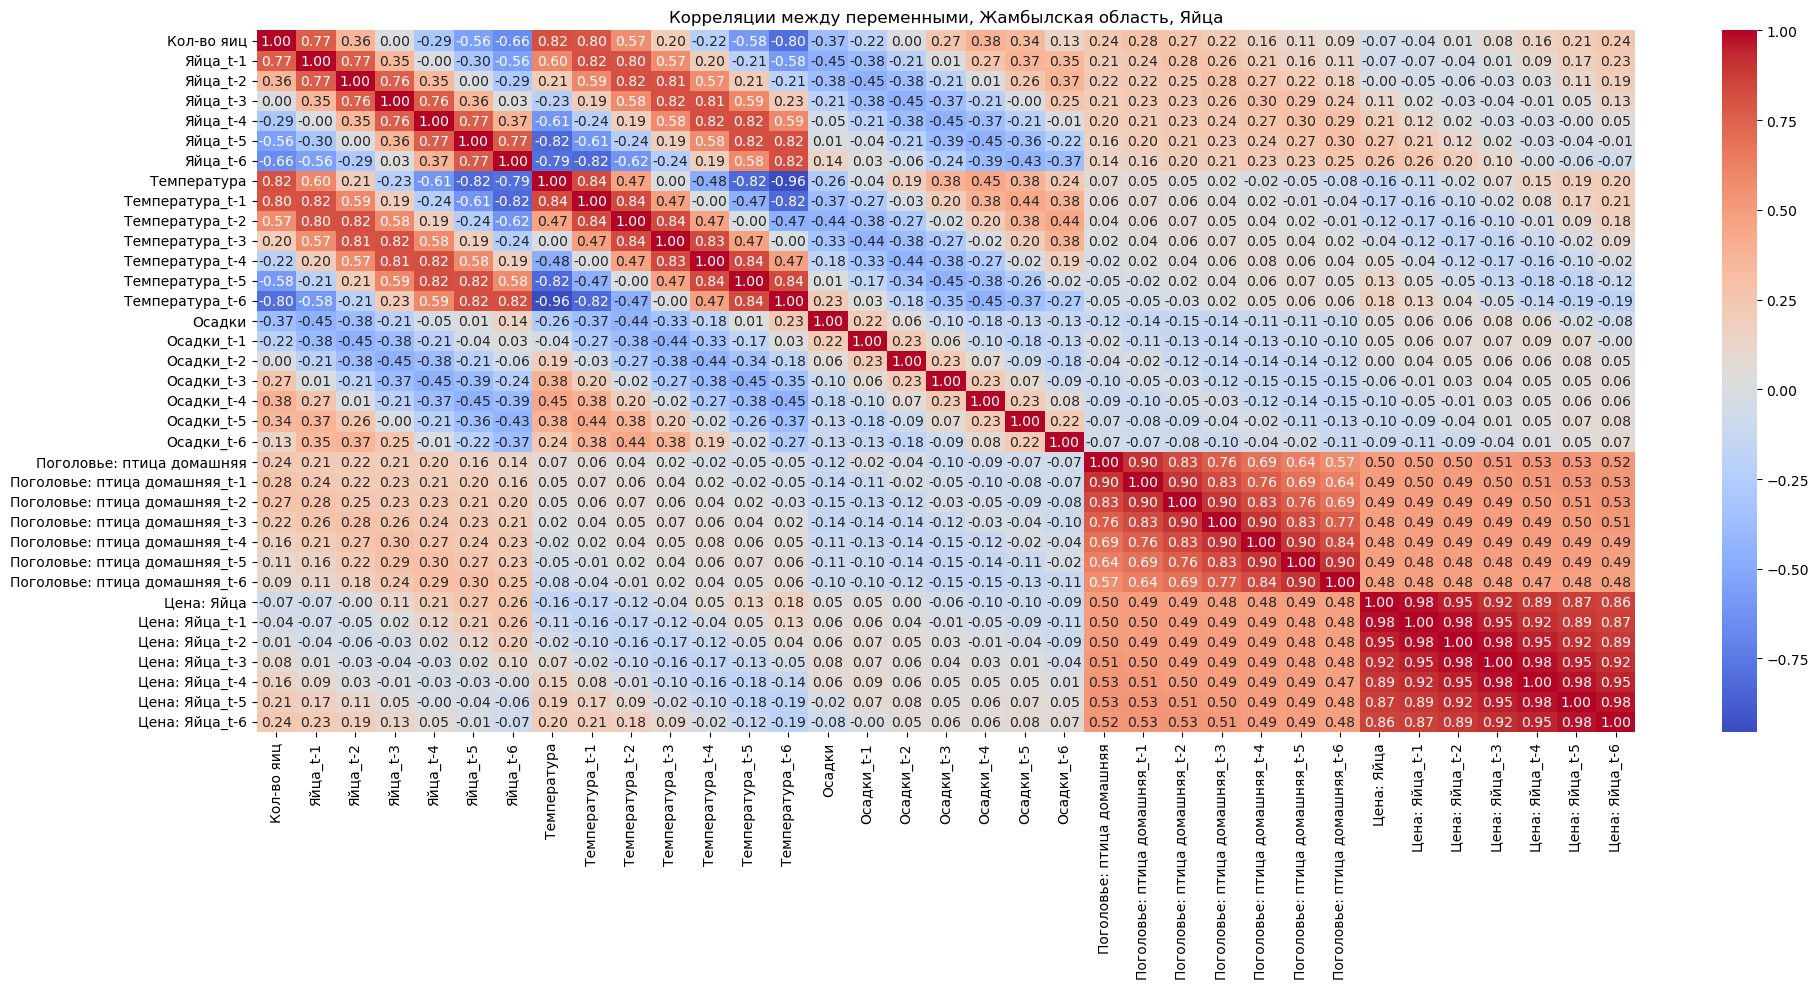

In [13]:
df_corr = df_zhambyl_full[[col for col in df_zhambyl_full.columns if col not in ["Период"]]].dropna().copy()

# 1. Correlation matrix
corr_matrix = df_corr.corr()

# 2. Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции между переменными, Жамбылская область, Яйца")
plt.tight_layout()
plt.show()

*ВЫВОДЫ ПО КОРРЕЛЯЦИИ*

In [14]:
# Set your target variable
target_var = "Кол-во яиц"

# Get correlations with the target variable
target_corr = corr_matrix[target_var].drop(target_var)  # exclude self-correlation

# Keep only features with |correlation| >= 0.5
selected_vars = target_corr[abs(target_corr) >= 0.45].index.tolist()

print("✅ Отобранные переменные с корреляцией >= 0.5:")
print(selected_vars)

# Optionally: create new dataframe with selected variables + target
df_selected = df_zhambyl_full[['Период'] + selected_vars + [target_var]]
df_selected

✅ Отобранные переменные с корреляцией >= 0.5:
['Яйца_t-1', 'Яйца_t-5', 'Яйца_t-6', 'Температура', 'Температура_t-1', 'Температура_t-2', 'Температура_t-5', 'Температура_t-6']


,Период,Яйца_t-1,Яйца_t-5,Яйца_t-6,Температура,Температура_t-1,Температура_t-2,Температура_t-5,Температура_t-6,Кол-во яиц
919,2015-01-01,NaN,NaN,NaN,-2.306452,NaN,NaN,NaN,NaN,6679.3
920,2015-02-01,6679.3,NaN,NaN,1.871429,-2.306452,NaN,NaN,NaN,5882.9
921,2015-03-01,5882.9,NaN,NaN,3.958065,1.871429,-2.306452,NaN,NaN,8486.3
922,2015-04-01,8486.3,NaN,NaN,14.166667,3.958065,1.871429,NaN,NaN,9293.0
923,2015-05-01,9293.0,NaN,NaN,20.106452,14.166667,3.958065,NaN,NaN,12289.6
...,...,...,...,...,...,...,...,...,...,...
1034,2024-08-01,18504.3,7596.5,6406.5,25.345161,25.758065,25.286667,5.535484,-2.175862,14534.9
1035,2024-09-01,14534.9,8548.5,7596.5,16.213333,25.345161,25.758065,12.786667,5.535484,11659.5
1036,2024-10-01,11659.5,11266.8,8548.5,11.387097,16.213333,25.345161,17.441935,12.786667,8246.6
1037,2024-11-01,8246.6,14618.4,11266.8,5.546667,11.387097,16.213333,25.286667,17.441935,7127.0


In [15]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()

X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Кол-во яиц"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
1,Яйца_t-1,4.035634
2,Яйца_t-5,5.466081
3,Яйца_t-6,5.556939
6,Температура_t-2,11.766398
7,Температура_t-5,12.229660
4,Температура,18.743660
8,Температура_t-6,19.426905
5,Температура_t-1,22.795043
0,const,115.820485


Step-by-Step Strategy to Handle High VIFs:

Sort VIFs in descending order
Drop variables one at a time, starting with the one that has the highest VIF.

Check domain relevance
Keep variables that are theoretically important or core to your hypothesis, even if VIF is high.

Evaluate correlation matrix
If two variables have high correlation with each other, and both have high VIFs, drop the one less correlated with the target.

Recalculate VIF after each drop
After dropping one variable, recalculate all VIFs. Sometimes removing just one variable significantly reduces others.

Use stepwise selection (optional)
Automated methods like backward elimination can help drop redundant predictors based on model fit and VIF thresholds.

In [16]:
df_selected = df_selected.drop(columns = [ 'Яйца_t-5', 'Яйца_t-6', 'Температура_t-1', 'Температура_t-2', 'Температура_t-5', 'Температура_t-6'])
df_selected

,Период,Яйца_t-1,Температура,Кол-во яиц
919,2015-01-01,NaN,-2.306452,6679.3
920,2015-02-01,6679.3,1.871429,5882.9
921,2015-03-01,5882.9,3.958065,8486.3
922,2015-04-01,8486.3,14.166667,9293.0
923,2015-05-01,9293.0,20.106452,12289.6
...,...,...,...,...
1034,2024-08-01,18504.3,25.345161,14534.9
1035,2024-09-01,14534.9,16.213333,11659.5
1036,2024-10-01,11659.5,11.387097,8246.6
1037,2024-11-01,8246.6,5.546667,7127.0


In [17]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()
X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Кол-во яиц"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
1,Яйца_t-1,1.551301
2,Температура,1.551301
0,const,13.633794


In [18]:
df_selected = df_selected.dropna().copy()
df_selected

,Период,Яйца_t-1,Температура,Кол-во яиц
920,2015-02-01,6679.3,1.871429,5882.9
921,2015-03-01,5882.9,3.958065,8486.3
922,2015-04-01,8486.3,14.166667,9293.0
923,2015-05-01,9293.0,20.106452,12289.6
924,2015-06-01,12289.6,25.026667,15259.7
...,...,...,...,...
1034,2024-08-01,18504.3,25.345161,14534.9
1035,2024-09-01,14534.9,16.213333,11659.5
1036,2024-10-01,11659.5,11.387097,8246.6
1037,2024-11-01,8246.6,5.546667,7127.0


### Models

#### Многофакторная регрессия

In [19]:
# Define target and features
y = df_selected["Кол-во яиц"]
X = df_selected.drop(columns=["Период", "Кол-во яиц"])

# Add constant term
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Кол-во яиц   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     223.4
Date:                Tue, 19 Aug 2025   Prob (F-statistic):           1.64e-40
Time:                        16:00:59   Log-Likelihood:                -1035.1
No. Observations:                 119   AIC:                             2076.
Df Residuals:                     116   BIC:                             2084.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4040.8132    497.000      8.130      

In [20]:
df_selected

,Период,Яйца_t-1,Температура,Кол-во яиц
920,2015-02-01,6679.3,1.871429,5882.9
921,2015-03-01,5882.9,3.958065,8486.3
922,2015-04-01,8486.3,14.166667,9293.0
923,2015-05-01,9293.0,20.106452,12289.6
924,2015-06-01,12289.6,25.026667,15259.7
...,...,...,...,...
1034,2024-08-01,18504.3,25.345161,14534.9
1035,2024-09-01,14534.9,16.213333,11659.5
1036,2024-10-01,11659.5,11.387097,8246.6
1037,2024-11-01,8246.6,5.546667,7127.0


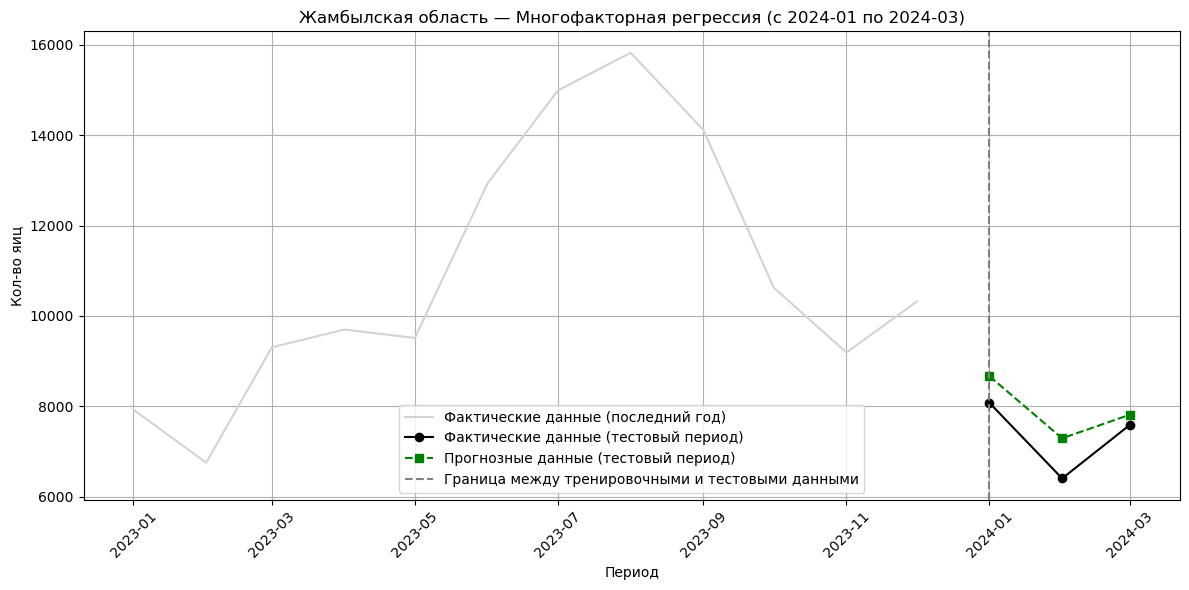

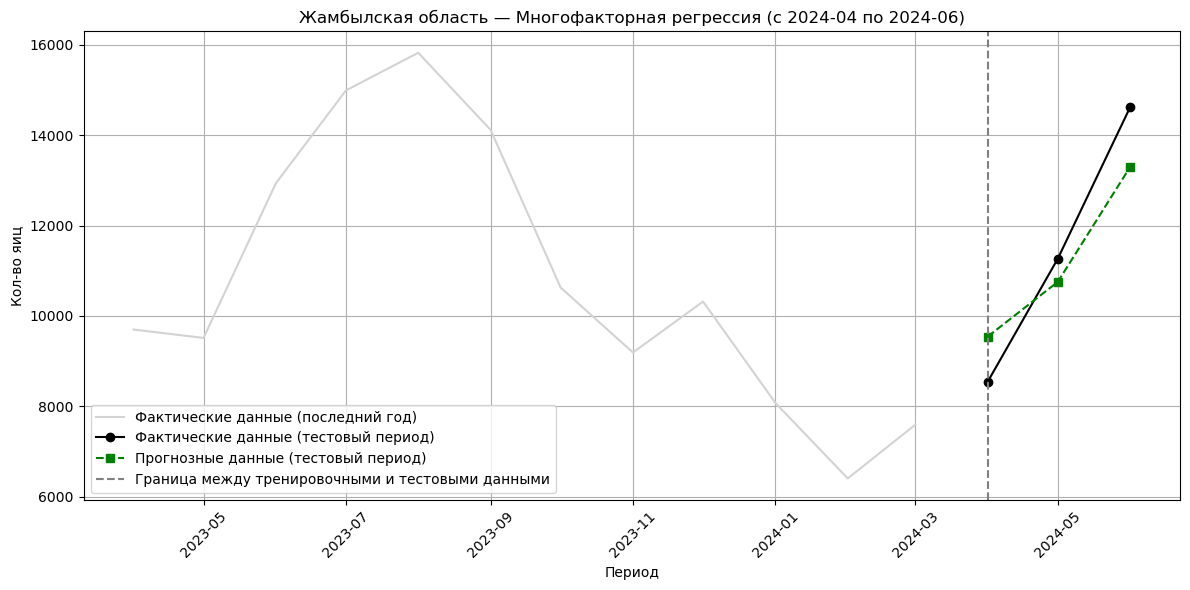

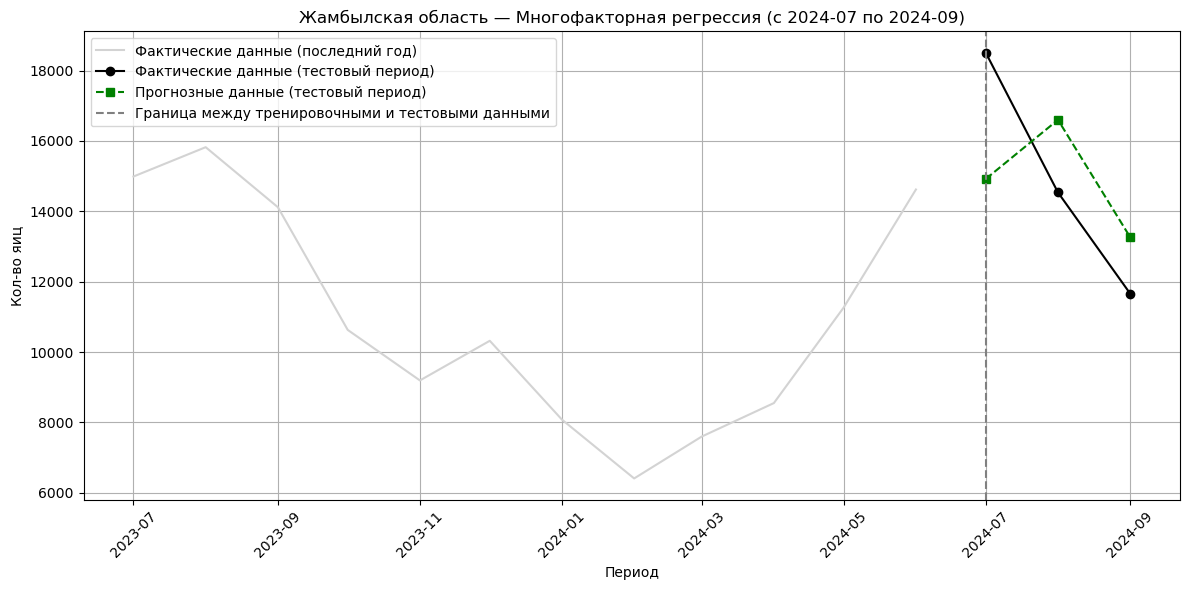

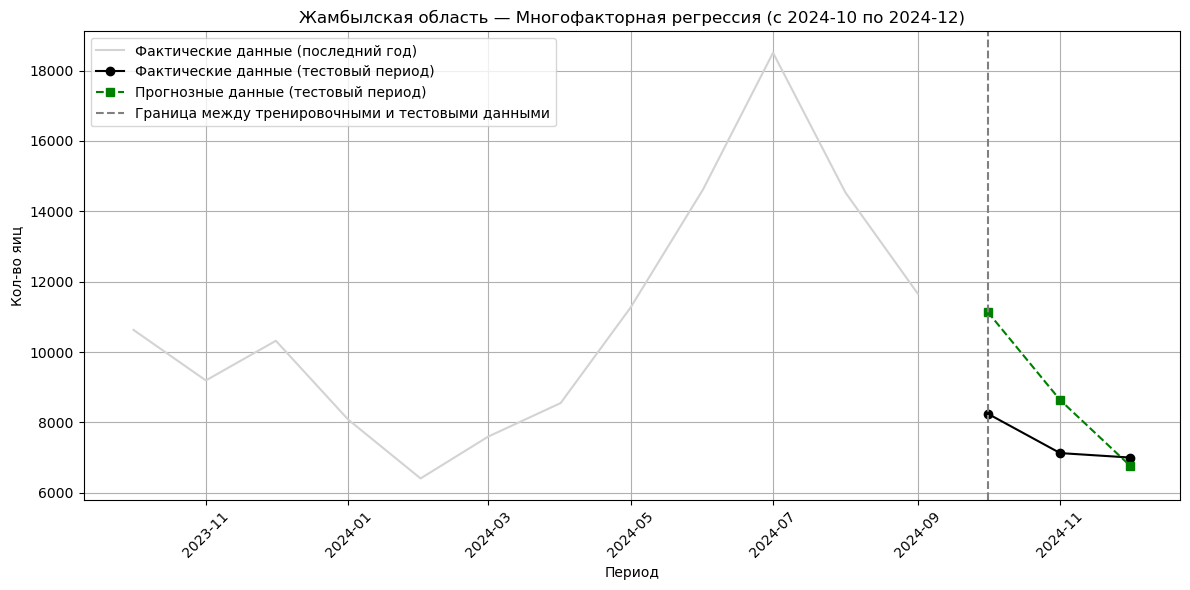

In [21]:
df = df_selected.sort_values("Период").copy()

target = "Кол-во яиц"
features = [col for col in df_selected.columns if col not in ['Период', 'Кол-во яиц']]

results = []

# Define 4 rolling test sets for 2024
start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

for start in start_dates:
    test_start = pd.to_datetime(start)
    test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Жамбылская область — Многофакторная регрессия (с {start} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Кол-во яиц")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [22]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-01 to 2024-03   628.548464   566.504435   8.026596
1  2024-04 to 2024-06  1000.161108   943.241827   8.412721
2  2024-07 to 2024-09  2562.033352  2417.901051  15.777925
3  2024-10 to 2024-12  1886.339878  1543.775728  19.846219
4             Average  1519.270700  1367.855760  13.015865


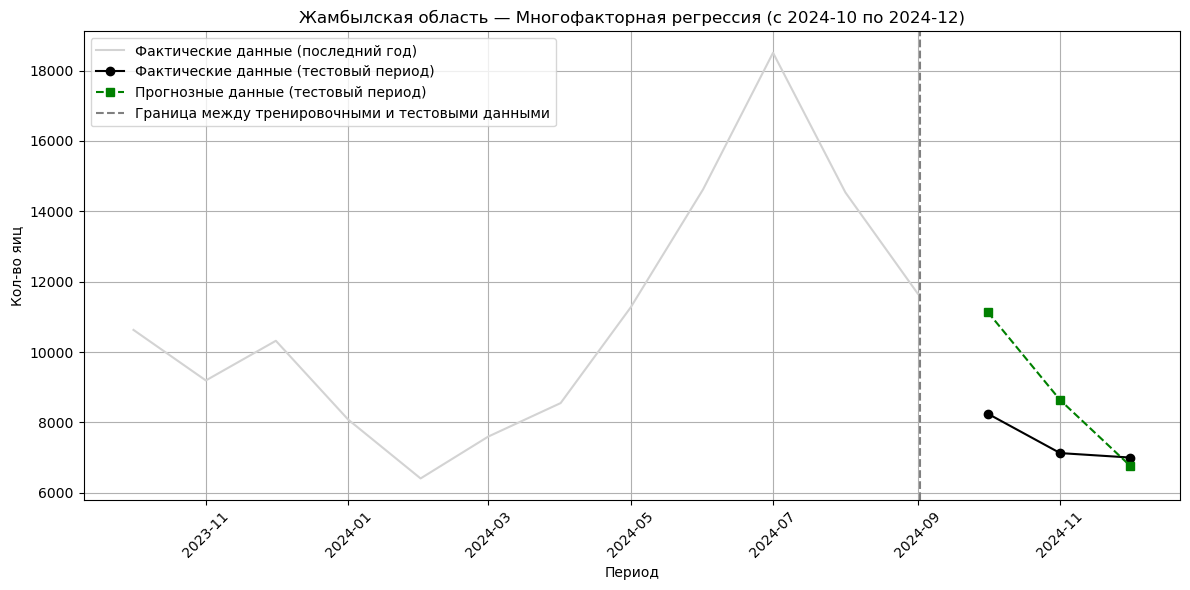

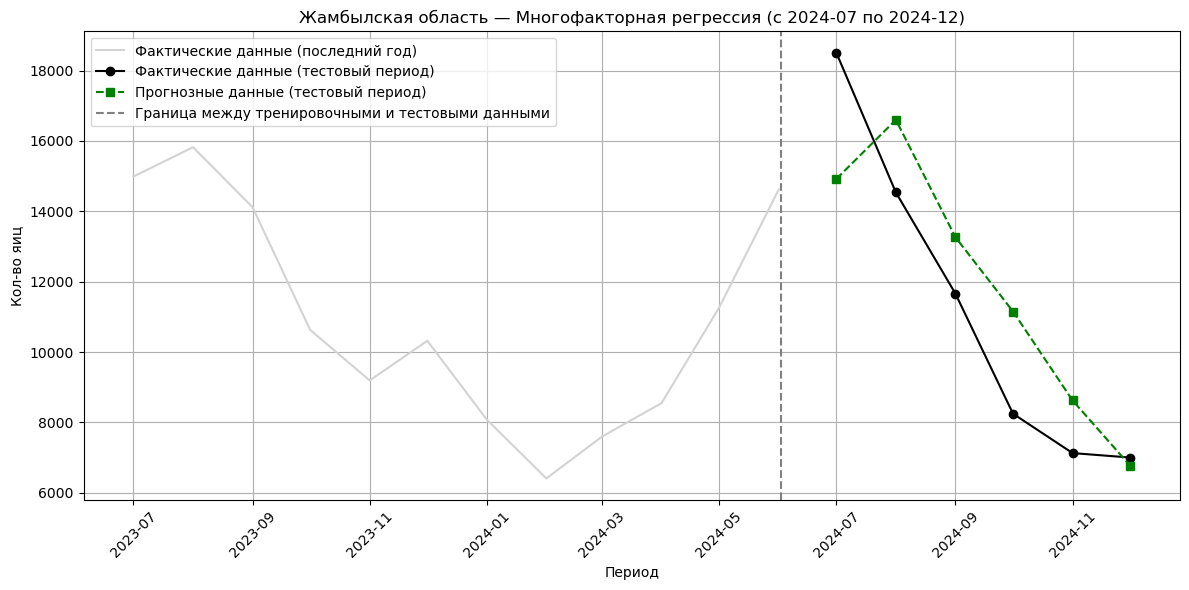

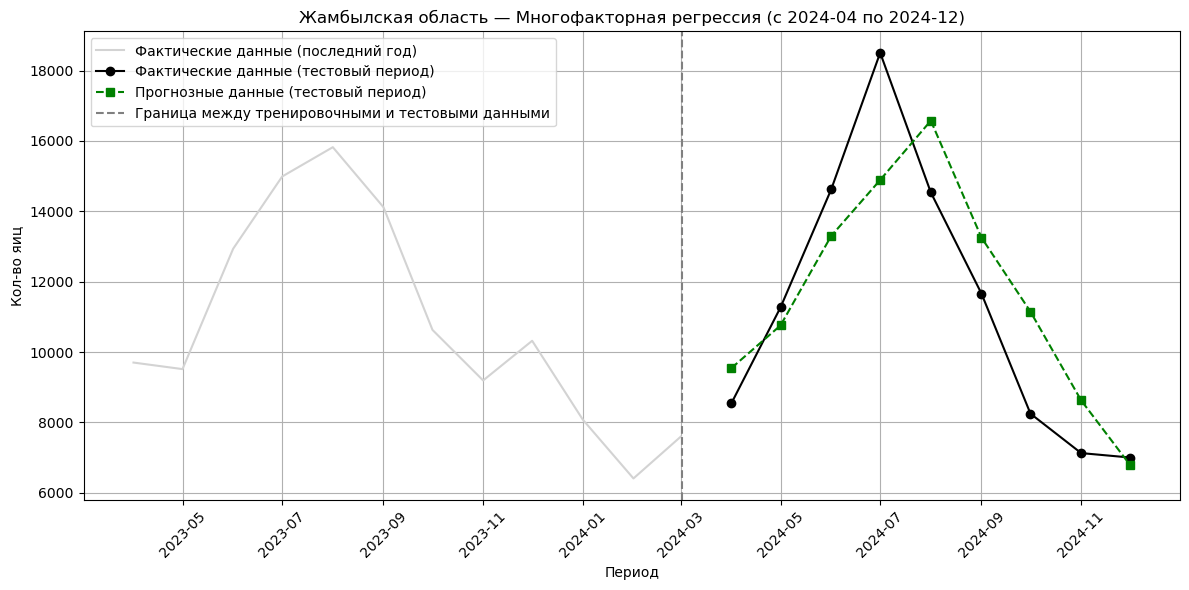

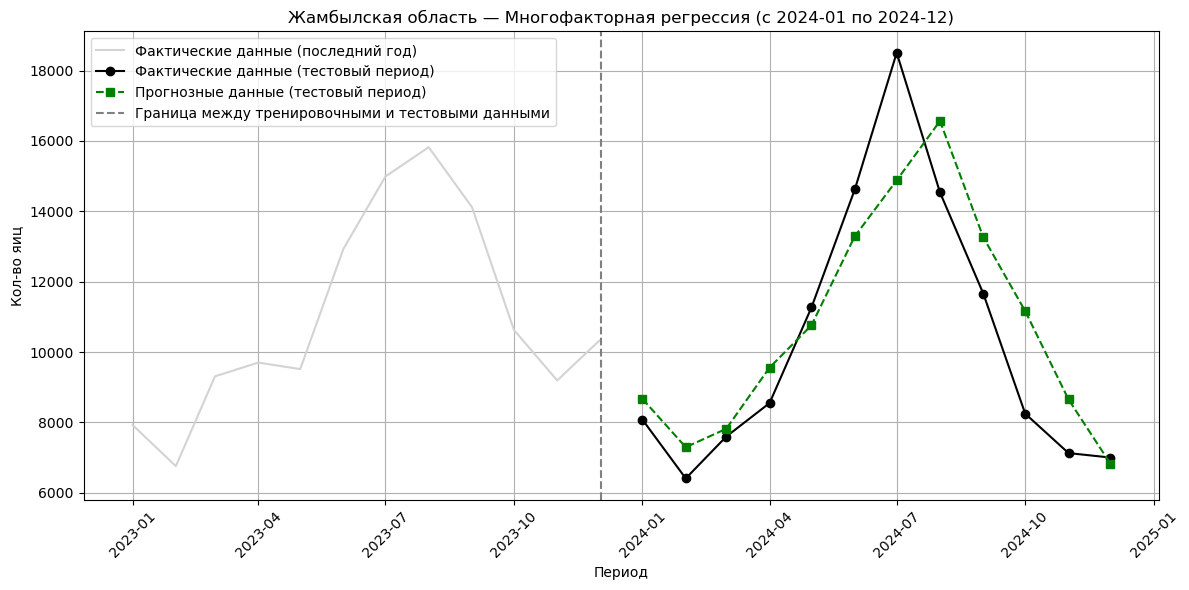

In [23]:
results = []

# Define 4 rolling test sets for 2024
horizons = [3, 6, 9, 12]

for horizon in horizons:

    test_end = pd.to_datetime("2024-12")
    test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Жамбылская область — Многофакторная регрессия (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Кол-во яиц")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-10 to 2024-12  1886.339878  1543.775728  19.846219
1  2024-07 to 2024-12  2251.484370  1980.813419  17.806999
2  2024-04 to 2024-12  1927.972035  1632.082821  14.634517
3  2024-01 to 2024-12  1705.295224  1367.944038  13.000268
4             Average  1942.772877  1631.154002  16.322001


#### SARIMA (auto-arima)

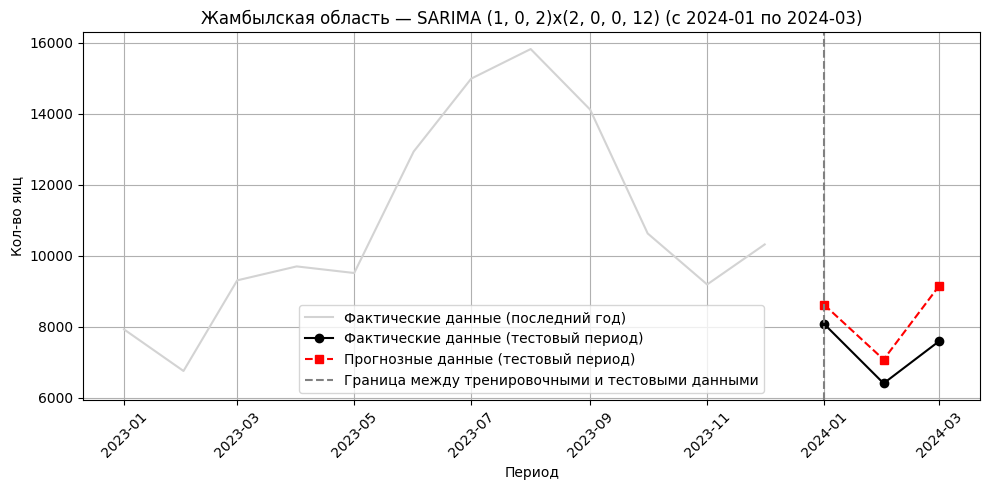

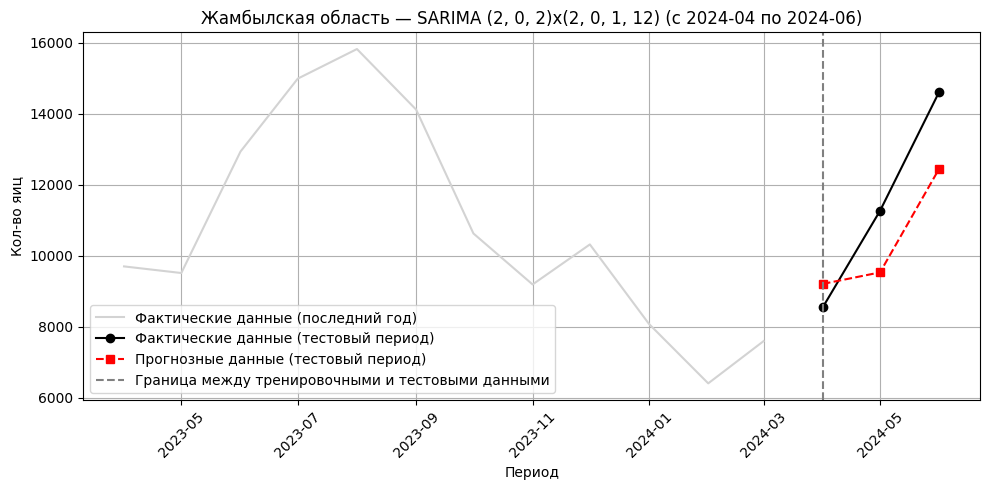

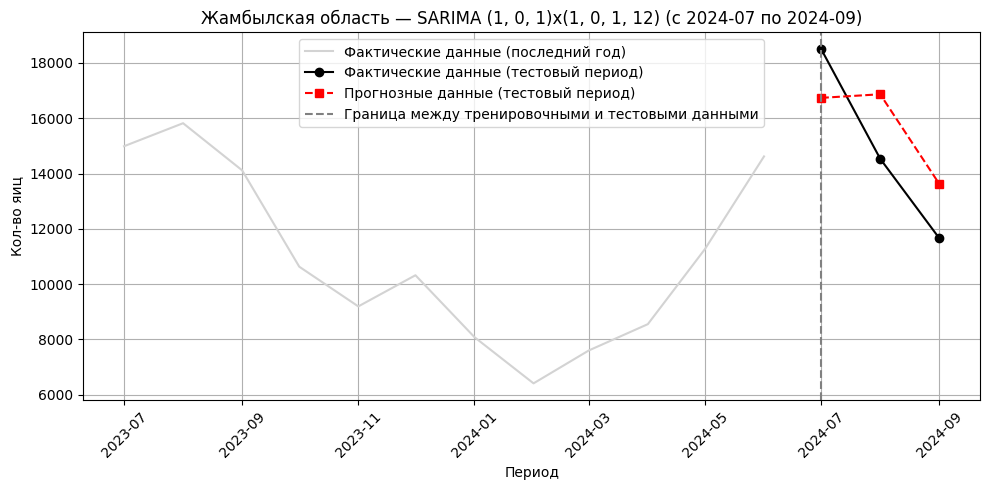

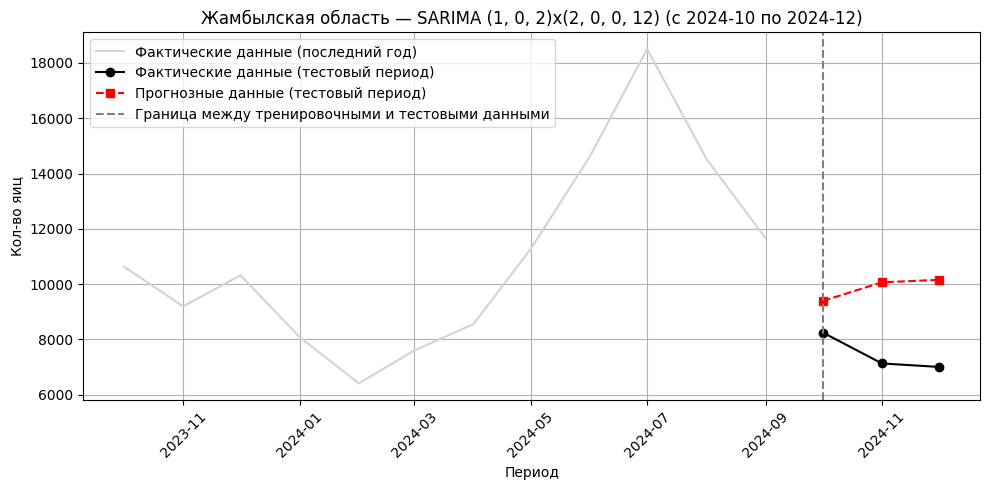

In [ ]:
# results = []

# # Определим 4 тестовых периода на 3 месяца
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Разделим данные
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=3)
#         forecast = pd.Series(forecast).reset_index(drop=True)


#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMA {model.order}x{model.seasonal_order} (с {test_start.strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Кол-во яиц")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()
#         # print("Zero values in y_test:", (y_test == 0).sum())


#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  1029.332279   924.509169  12.575939    (1, 0, 2)   
1  2024-04 to 2024-06  1645.982439  1519.319857  12.636867    (2, 0, 2)   
2  2024-07 to 2024-09  2035.709405  2022.150083  14.155983    (1, 0, 1)   
3  2024-10 to 2024-12  2572.964619  2409.986535  33.356363    (1, 0, 2)   
4             Average  1820.997185  1718.991411  18.181288          NaN   

  Seasonal order  
0  (2, 0, 0, 12)  
1  (2, 0, 1, 12)  
2  (1, 0, 1, 12)  
3  (2, 0, 0, 12)  
4            NaN  


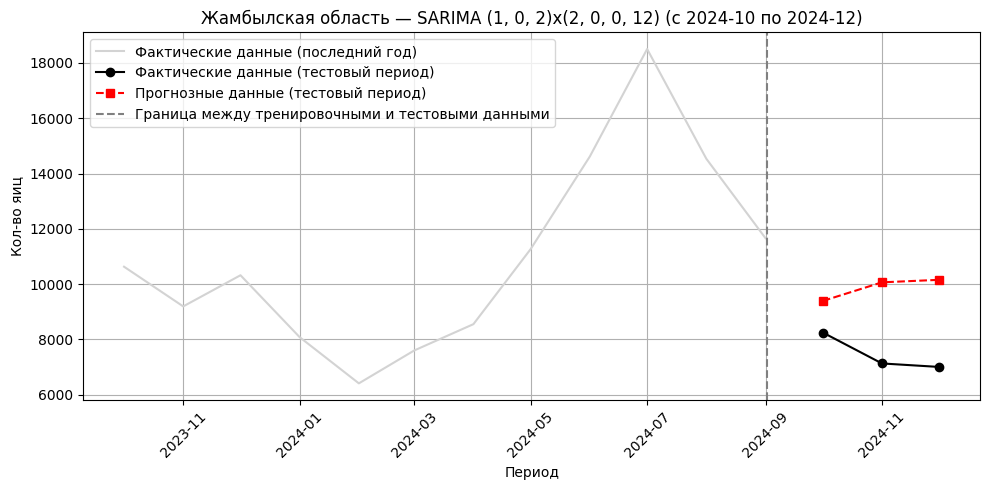

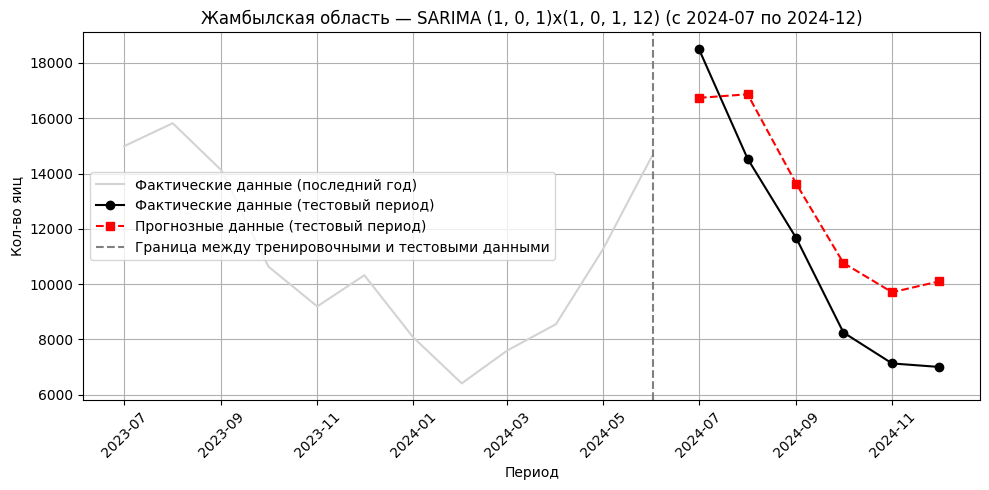

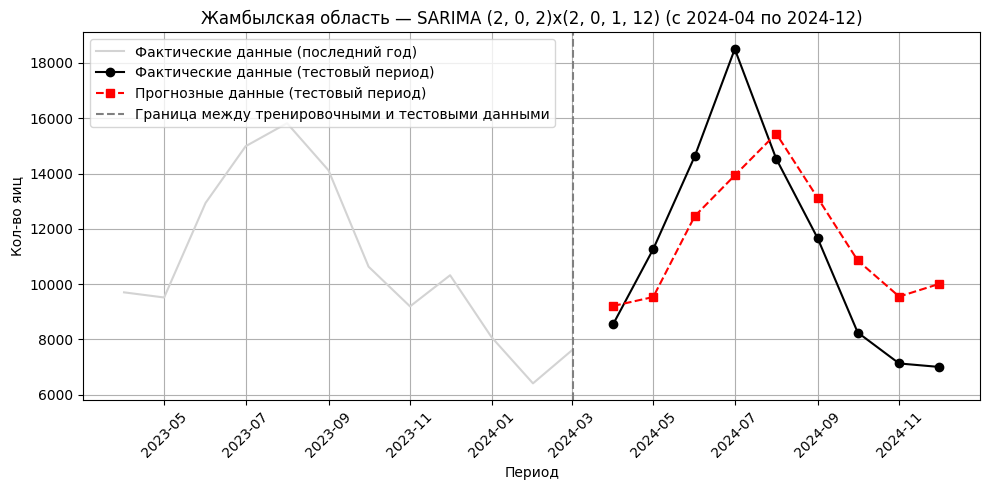

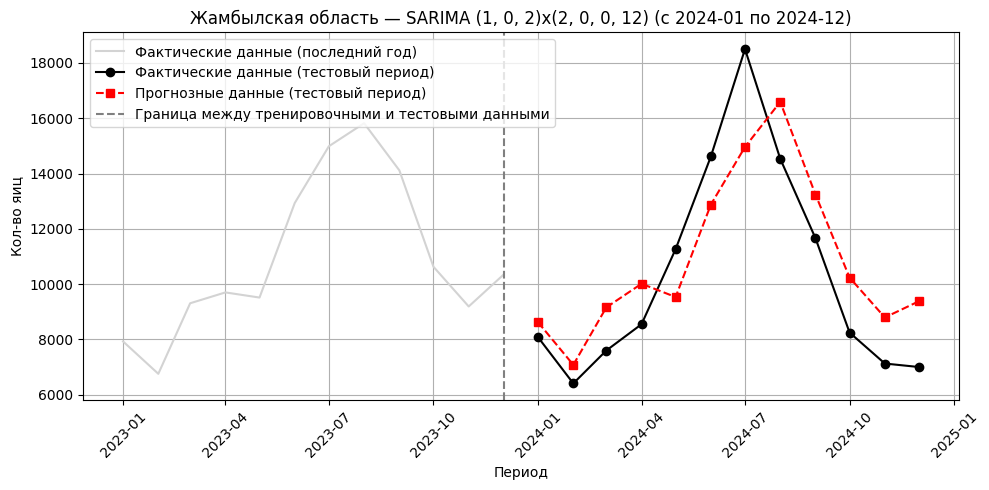

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:

#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)
    
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=horizon)
#         forecast = pd.Series(forecast).reset_index(drop=True)

#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMA {model.order}x{model.seasonal_order} (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Кол-во яиц")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12  2572.964619  2409.986535  33.356363    (1, 0, 2)   
1  2024-07 to 2024-12  2414.688679  2375.744146  25.558201    (1, 0, 1)   
2  2024-04 to 2024-12  2442.303710  2170.399644  21.101378    (2, 0, 2)   
3  2024-01 to 2024-12  1893.846325  1744.109223  17.542995    (1, 0, 2)   
4             Average  2330.950833  2175.059887  24.389734          NaN   

  Seasonal order  
0  (2, 0, 0, 12)  
1  (1, 0, 1, 12)  
2  (2, 0, 1, 12)  
3  (2, 0, 0, 12)  
4            NaN  


#### SARIMAX

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


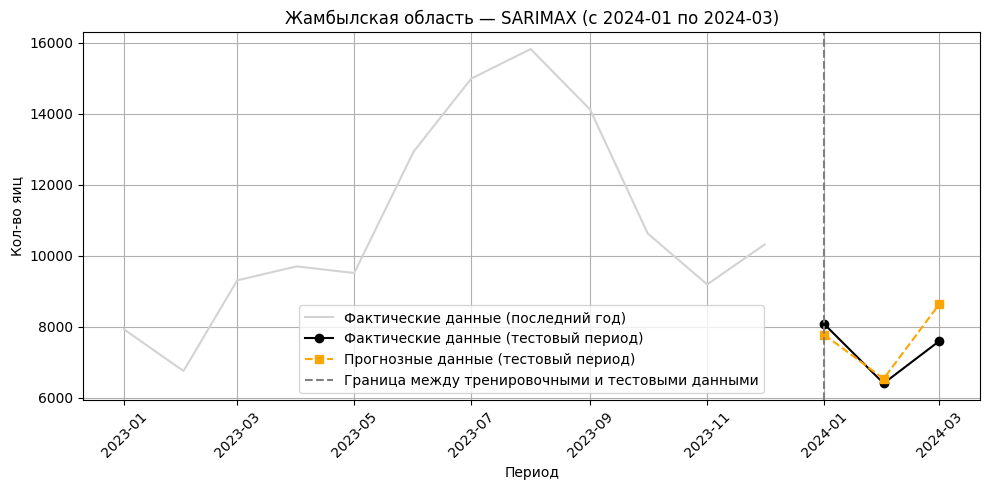

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


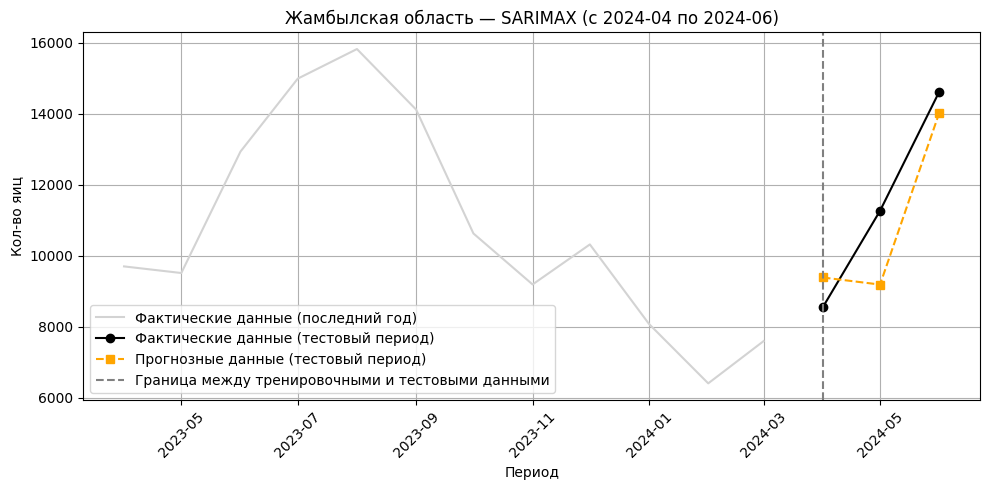

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


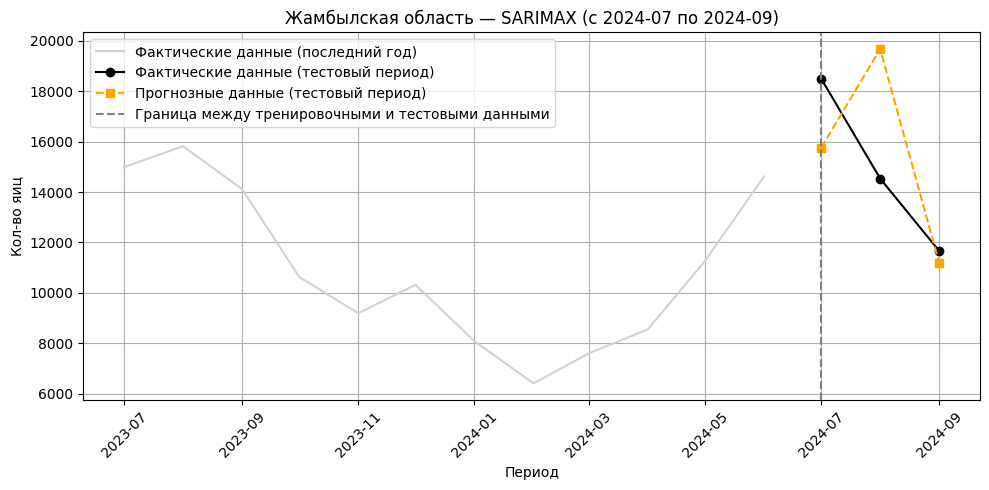

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


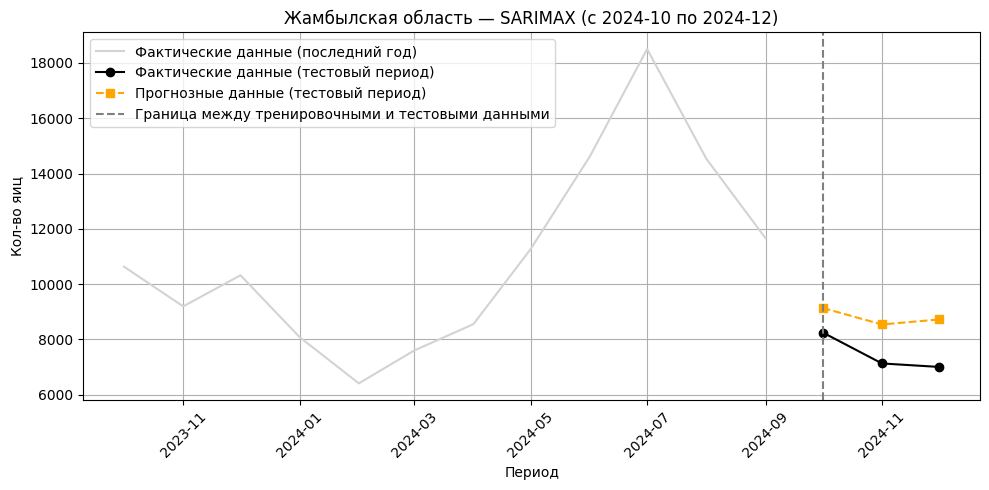

In [ ]:
# results = []

# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(1, 0, 2),
#             seasonal_order=(2, 0, 0, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=3, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMAX (с {start} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Кол-во яиц")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)



          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03   628.509149   489.079920   6.466369            1   
1  2024-04 to 2024-06  1339.176204  1171.476174  10.782544            1   
2  2024-07 to 2024-09  3378.379896  2791.070482  18.121203            1   
3  2024-10 to 2024-12  1382.426955  1339.178301  18.371658            1   
4             Average  1682.123051  1447.701219  13.435444                

  Seasonal order  
0             24  
1             24  
2             24  
3             24  
4                 


c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


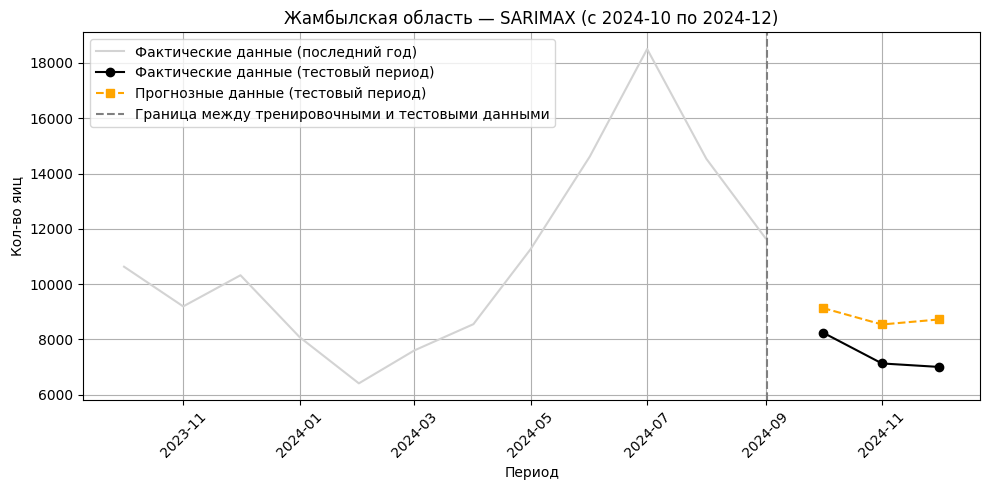

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


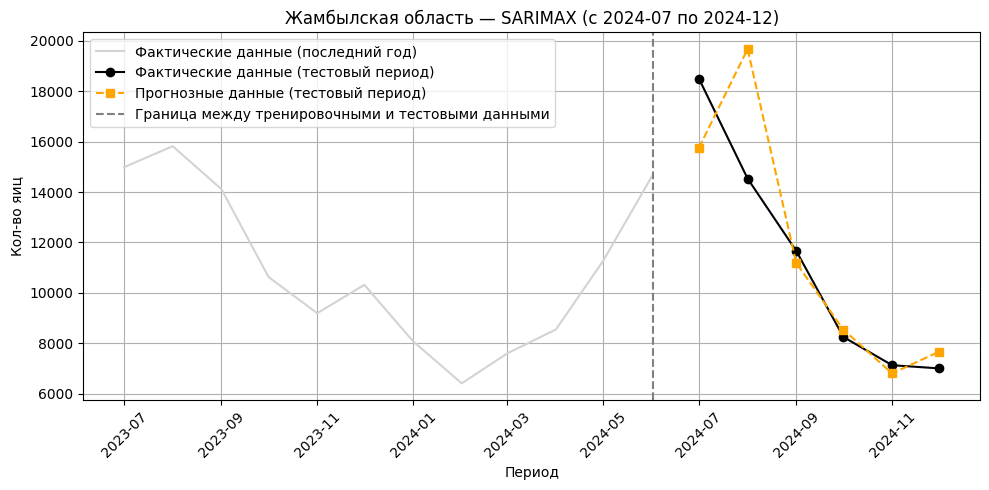

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


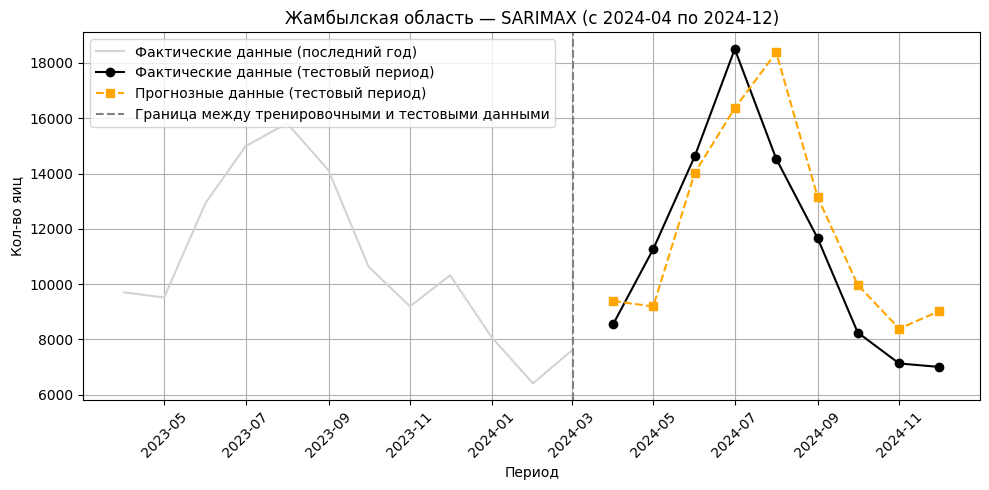

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


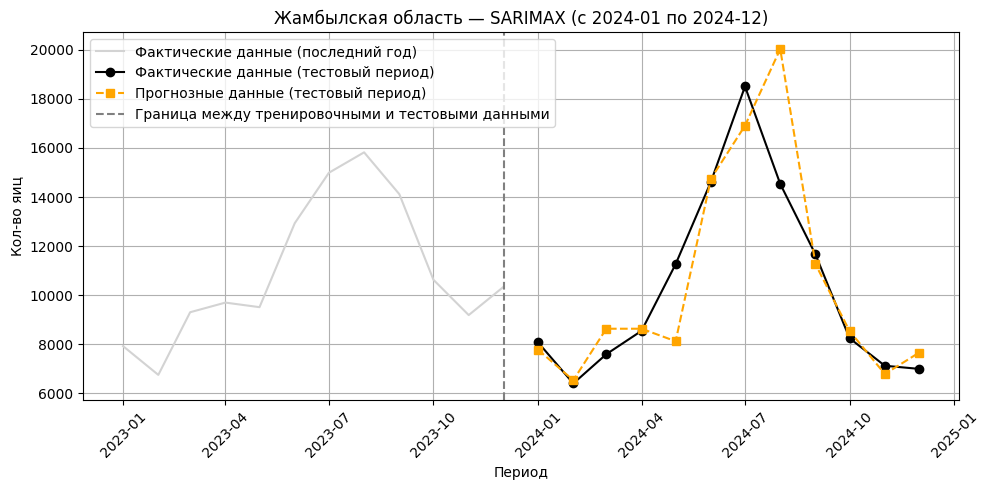

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:
#     # test_start = pd.to_datetime(start)
#     # test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(1, 0, 2),
#             seasonal_order=(2, 0, 0, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=horizon, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMAX (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Кол-во яиц")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)

          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12  1382.426955  1339.178301  18.371658            1   
1  2024-07 to 2024-12  2410.889672  1609.214200  11.994668            1   
2  2024-04 to 2024-12  1989.606314  1777.525377  16.735065            1   
3  2024-01 to 2024-12  1927.694341  1132.744471   9.720112            1   
4             Average  1927.654320  1464.665587  14.205376                

  Seasonal order  
0             24  
1             24  
2             24  
3             24  
4                 


#### Prophet

16:53:15 - cmdstanpy - INFO - Chain [1] start processing
16:53:15 - cmdstanpy - INFO - Chain [1] done processing


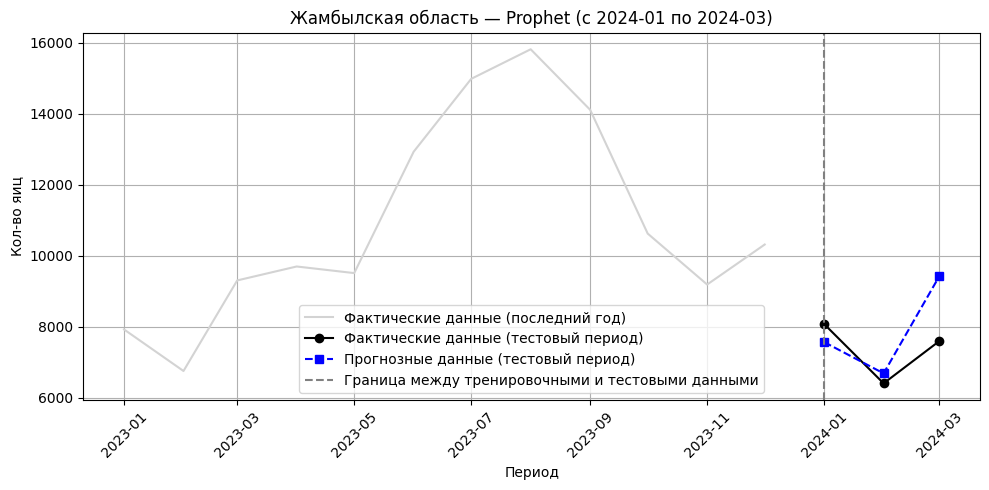

16:53:15 - cmdstanpy - INFO - Chain [1] start processing
16:53:16 - cmdstanpy - INFO - Chain [1] done processing


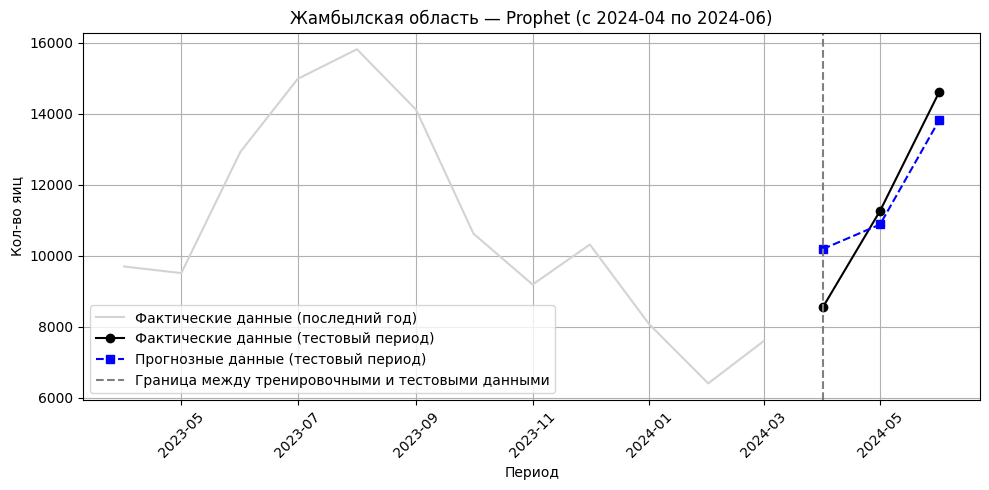

16:53:16 - cmdstanpy - INFO - Chain [1] start processing
16:53:16 - cmdstanpy - INFO - Chain [1] done processing


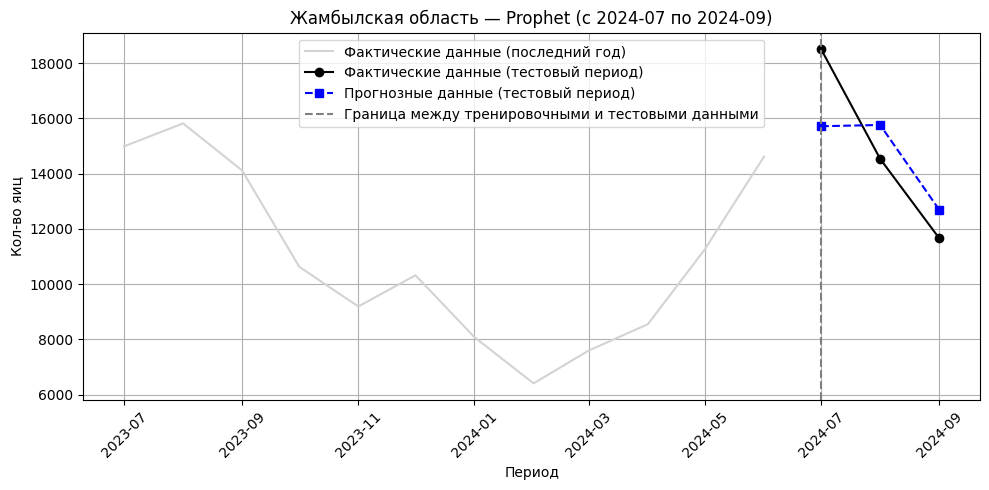

16:53:17 - cmdstanpy - INFO - Chain [1] start processing
16:53:17 - cmdstanpy - INFO - Chain [1] done processing


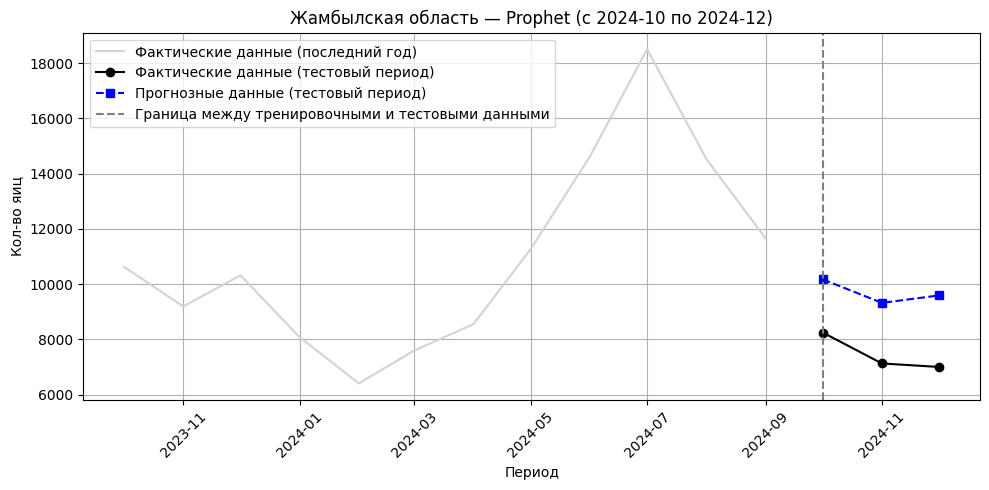

In [ ]:
# results = []

# # Define 4 test periods
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Train/test split
#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Initialize Prophet
#     model = Prophet()

#     # Optional: add regressors
#     # model.add_regressor("Температура_t-1")
#     # prophet_train["Температура_t-1"] = train_df["Температура_t-1"].values
#     # prophet_test["Температура_t-1"] = test_df["Температура_t-1"].values

#     # Fit
#     model.fit(prophet_train)

#     # Create future dataframe
#     future = model.make_future_dataframe(periods=3, freq="M")
#     forecast = model.predict(future)
# # forecast
# # prophet_test

#     # Extract forecast for test period only
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluate
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Жамбылская область — Prophet (с {start} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Кол-во яиц")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()



In [ ]:
# results_df = pd.DataFrame(results)
# avg = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg])], ignore_index=True)
# print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-01 to 2024-03  1106.319642   871.864192  11.573694
1  2024-04 to 2024-06  1076.620575   939.972169   9.351391
2  2024-07 to 2024-09  1856.179394  1681.987581  10.784668
3  2024-10 to 2024-12  2253.659770  2236.975891  30.383849
4             Average  1573.194845  1432.699958  15.523400


16:53:17 - cmdstanpy - INFO - Chain [1] start processing
16:53:17 - cmdstanpy - INFO - Chain [1] done processing


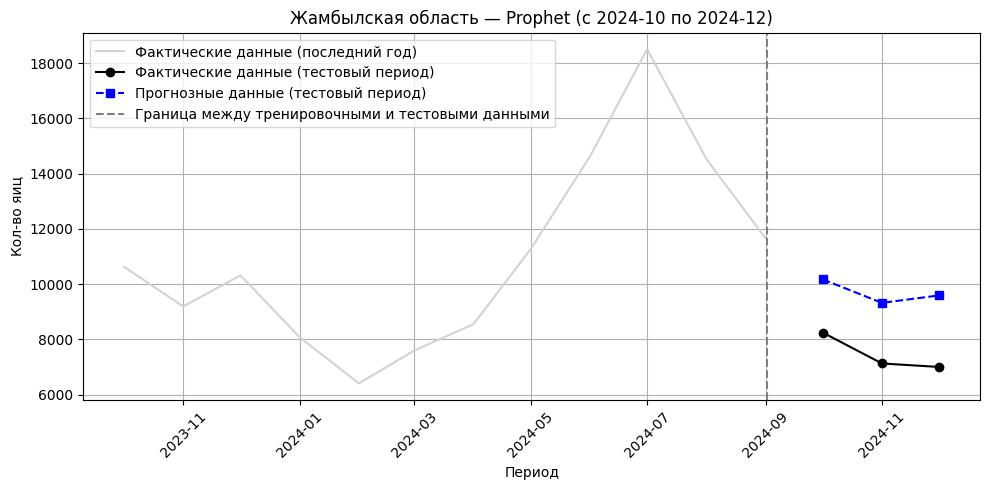

16:53:18 - cmdstanpy - INFO - Chain [1] start processing
16:53:18 - cmdstanpy - INFO - Chain [1] done processing


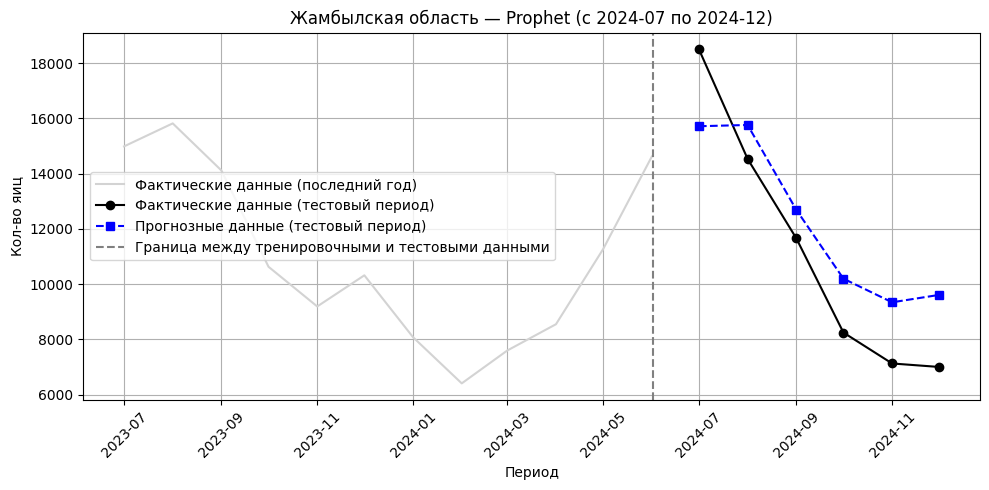

16:53:18 - cmdstanpy - INFO - Chain [1] start processing
16:53:18 - cmdstanpy - INFO - Chain [1] done processing


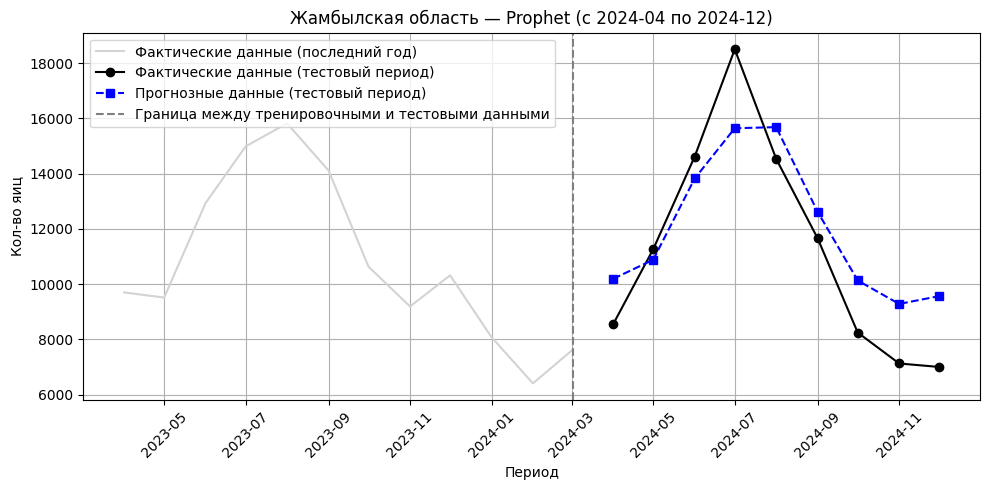

16:53:19 - cmdstanpy - INFO - Chain [1] start processing
16:53:19 - cmdstanpy - INFO - Chain [1] done processing


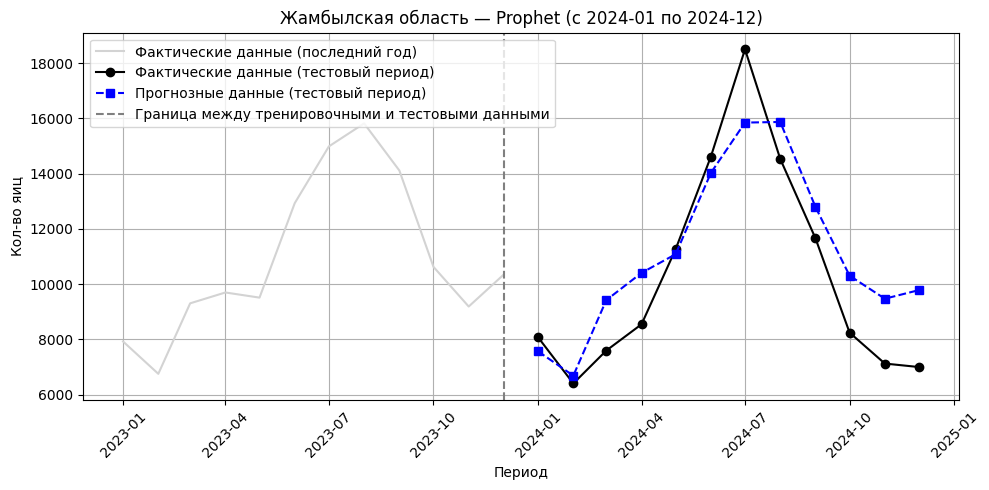

In [ ]:
# horizons = [3, 6, 9, 12]
# results = []

# for horizon in horizons:

#     # Define train/test split
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Fit Prophet
#     model = Prophet()
#     model.fit(prophet_train)

#     # Forecast
#     future = model.make_future_dataframe(periods=horizon, freq="M")
#     forecast = model.predict(future)

#     # Extract matching forecasted months
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluation
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Жамбылская область — Prophet (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Кол-во яиц")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()




In [ ]:
# # Summary table
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-10 to 2024-12  2253.659770  2236.975891  30.383849
1  2024-07 to 2024-12  2076.105298  1970.332257  20.729176
2  2024-04 to 2024-12  1785.248071  1599.647775  16.602342
3  2024-01 to 2024-12  1711.527024  1464.029337  16.094096
4                 NaN  1956.635041  1817.746315  20.952366


strength of correlation:
https://link.springer.com/article/10.1057/jt.2009.5#
https://resources.nu.edu/statsresources/correlation